#Spam Classification

Imports

In [60]:
import zipfile
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize,TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer,SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report



# Download the required model
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Extracting and analyzing Dataset

In [2]:
with zipfile.ZipFile('/content/spam.zip') as zf:
  zf.extractall('/content/Spam classification')

In [3]:
path='/content/Spam classification/spam.csv'

In [4]:
df=pd.read_csv(path,encoding='latin-1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


V1 and v2 have no null values
v3 and v4 have most missing values

In [6]:
df.shape

(5572, 5)

In [7]:
df.isnull().any()

,0
v1,False
v2,False
Unnamed: 2,True
Unnamed: 3,True
Unnamed: 4,True


In [8]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


Dropping columns named 'Unamed' 2 3 and 4

In [9]:
df=df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)

In [10]:
df=df.rename(columns={'v1':'target','v2':'text'})

In [11]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.groupby('target')['target'].count()

,target
target,
ham,4825
spam,747


Some Duplicate values exist in data

In [13]:
df['text'][df.duplicated()]

,text
102,As per your request 'Melle Melle (Oru Minnamin...
153,As per your request 'Melle Melle (Oru Minnamin...
206,"As I entered my cabin my PA said, '' Happy B'd..."
222,"Sorry, I'll call later"
325,No calls..messages..missed calls
...,...
5524,You are awarded a SiPix Digital Camera! call 0...
5535,"I know you are thinkin malaria. But relax, chi..."
5539,Just sleeping..and surfing
5553,Hahaha..use your brain dear


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

Coverting target column to binary discrete variable

In [16]:
df['target']=df['target'].map(lambda x: 1 if x=='spam' else 0)

Helper function to convert text into lowercase

In [17]:
def lowercase(text):

  return text.lower()

In [18]:
df['text']=df['text'].map(lowercase)

In [19]:
df['text'][0]

'go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...'

Creating word tokens

In [20]:
tweet_tokenizer=TweetTokenizer()

In [21]:
df['text']=df['text'].map(lambda x: tweet_tokenizer.tokenize(x))

In [22]:
df.head()

,target,text
0,0,"[go, until, jurong, point, ,, crazy, .., avail..."
1,0,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,1,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,0,"[u, dun, say, so, early, hor, ..., u, c, alrea..."
4,0,"[nah, i, don't, think, he, goes, to, usf, ,, h..."


Applying a stemming/lemmatization technique

In [23]:
P_stemmer=PorterStemmer()
wnl=WordNetLemmatizer()
s_stemmer=SnowballStemmer(language='english')

In [24]:
def p_stem(text):
  l=[]
  for i in text:
    l.append(P_stemmer.stem(i))
  return l


In [25]:
def wnl_stem(text):
  l=[]
  for i in text:
    l.append(wnl.lemmatize(i))
  return l

In [26]:
def s_stem(text):
  l=[]
  for i in text:
    l.append(s_stemmer.stem(i))
  return l

Remoiving the stop_words

In [27]:
stop_words=set(stopwords.words('english'))

In [28]:
def remove_stopwords(text):
  l=[]
  for i in text:
    if i not in stop_words:
      l.append(i)
  return l

In [29]:
df['text']=df['text'].map(remove_stopwords)

In [30]:
p_stemmed_df=df.copy()
wnl_stemmed_df=df.copy()
s_stemmed_df=df.copy()

In [31]:
#choosing porter stemmer for now
p_stemmed_df['text']=p_stemmed_df['text'].map(p_stem)

In [32]:
p_stemmed_df.head()

,target,text
0,0,"[go, jurong, point, ,, crazi, .., avail, bugi,..."
1,0,"[ok, lar, ..., joke, wif, u, oni, ...]"
2,1,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,"[u, dun, say, earli, hor, ..., u, c, alreadi, ..."
4,0,"[nah, think, goe, usf, ,, live, around, though]"


In [33]:
s_stemmed_df['text']=s_stemmed_df['text'].map(s_stem)

In [34]:
s_stemmed_df.head()

,target,text
0,0,"[go, jurong, point, ,, crazi, .., avail, bugi,..."
1,0,"[ok, lar, ..., joke, wif, u, oni, ...]"
2,1,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,"[u, dun, say, earli, hor, ..., u, c, alreadi, ..."
4,0,"[nah, think, goe, usf, ,, live, around, though]"


In [35]:
wnl_stemmed_df['text']=wnl_stemmed_df['text'].map(wnl_stem)

In [36]:
wnl_stemmed_df.head()

,target,text
0,0,"[go, jurong, point, ,, crazy, .., available, b..."
1,0,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,1,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,0,"[u, dun, say, early, hor, ..., u, c, already, ..."
4,0,"[nah, think, go, usf, ,, life, around, though]"


In [37]:
def convert_tokens_to_text(text):
  return ' '.join(text)

In [38]:
p_stemmed_df['text']=p_stemmed_df['text'].map(convert_tokens_to_text)
s_stemmed_df['text']=s_stemmed_df['text'].map(convert_tokens_to_text)
wnl_stemmed_df['text']=wnl_stemmed_df['text'].map(convert_tokens_to_text)


lets choose snowball stemmed text for now

In [39]:
final_df=s_stemmed_df.copy()

In [40]:
final_df.head()

,target,text
0,0,"go jurong point , crazi .. avail bugi n great ..."
1,0,ok lar ... joke wif u oni ...
2,1,free entri 2 wkli comp win fa cup final tkts 2...
3,0,u dun say earli hor ... u c alreadi say ...
4,0,"nah think goe usf , live around though"


Train test split

In [41]:
X=final_df['text']
y=final_df['target']

In [46]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [49]:
models={
    'MultinomialNB':
     (
         MultinomialNB(),
         {
             'model__alpha':[0.1,0.5,1.0,1.5,2.0]
          }
     ),
    'LogisticRegression':
     (
         LogisticRegression(),
         {
             'model__C':[0.1,0.5,1.0,1.5,2.0]
          }
     ),

    'RandomForestClassifier':(
        RandomForestClassifier(),
        {
            'model__n_estimators':[10,50,100,150],
            'model__max_depth':[None,10,20,30],
        }
        ),
    'XGBClassifier':(
        XGBClassifier(),
        {
            'model__n_estimators':[10,50,100,150],
            'model__max_depth':[None,10,20,30],
        }
        )
        }



In [50]:
results = {}


for model_name, (model_instance, param_grid) in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', model_instance)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='f1')

    grid_search.fit(x_train, y_train)

    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'best_estimator': grid_search.best_estimator_
    }

# 3. View comparison
for name, res in results.items():
    print(f"Model: {name} | Best CV Score: {res['best_score']:.4f}")
    print(f"Best Params: {res['best_params']}\n")

Model: MultinomialNB | Best CV Score: 0.9278
Best Params: {'model__alpha': 0.1}

Model: LogisticRegression | Best CV Score: 0.8645
Best Params: {'model__C': 2.0}

Model: RandomForestClassifier | Best CV Score: 0.8929
Best Params: {'model__max_depth': None, 'model__n_estimators': 100}

Model: XGBClassifier | Best CV Score: 0.8611
Best Params: {'model__max_depth': 10, 'model__n_estimators': 50}



In [52]:
best_model_name = max(results, key=lambda name: results[name]['best_score'])
best_pipeline = results[best_model_name]['best_estimator']

In [54]:
best_pipeline


Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('model', MultinomialNB(alpha=0.1))])

In [64]:
y_pred=best_pipeline.predict(x_test)

In [65]:
cm=confusion_matrix(y_test,y_pred)

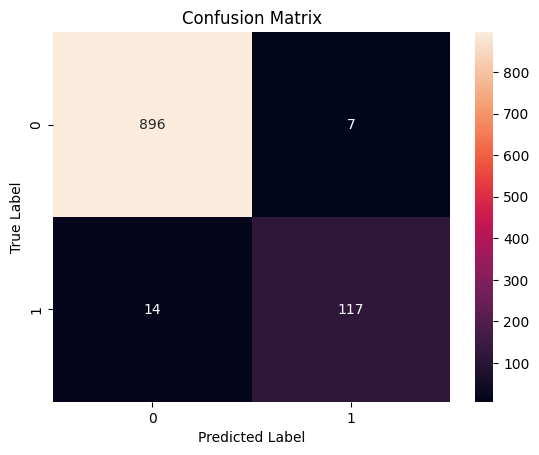

In [66]:
plt.figure()
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [59]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.94      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



Saving the best pipeline

In [61]:
joblib.dump(best_pipeline,'best_spam_classifier.pkl')

['best_spam_classifier.pkl']